# WarpKriging with Kumaraswamy warping (Python)

The **Kumaraswamy** warp applies the CDF $w(x) = 1 - (1-x^a)^b$ on $[0,1]$.
This flexible monotone transformation can capture skewness and concentration effects in the input space.

Steps:
1. Install pylibkriging (run once)
2. Load pylibkriging
3. Define the Branin function and plot it
4. Build a space-filling design and evaluate it
5. Fit a `WarpKriging` model
6. Predict on a fine grid and plot mean + uncertainty
7. Inspect model parameters

## 0. Installation

Set `REPO_ROOT`, then optionally create a venv and install build requirements
(skip the build cells if pylibkriging is already installed).

In [1]:
%%bash
REPO_ROOT=$(cd ../.. && pwd)
echo "REPO_ROOT=${REPO_ROOT}"

REPO_ROOT=/home/richet/Sync/Open/libKriging/alien/libKriging


In [2]:
%%bash
# Optional: skip if pylibkriging is already installed
set -e
REPO_ROOT=$(cd ../.. && pwd)
VENV_DIR=./venv

# Create venv if needed
if [ ! -d "${VENV_DIR}" ]; then
    python3 -m venv "${VENV_DIR}"
fi
source "${VENV_DIR}/bin/activate"

# Install build requirements
pip install -q \
    -r "${REPO_ROOT}/bindings/Python/pylibkriging/requirements.txt" \
    -r "${REPO_ROOT}/bindings/Python/pylibkriging/dev-requirements.txt"

pip install matplotlib

lib) (1.3.3)


 (0.12.1)


tlib) (4.62.1)


tlib) (1.5.0)


(1.26.4)


ib) (26.0)


2.1.1)


 (3.3.2)


plotlib) (2.9.0.post0)


>=2.7->matplotlib) (1.17.0)


In [3]:
%%bash
# Optional: compile libkriging from source if not already built
set -e
REPO_ROOT=$(cd ../.. && pwd)

    cd "${REPO_ROOT}"
    # Point repo-level venv to our local one so loadenv.sh picks it up
    if [ ! -e venv ]; then
        ln -s bindings/Python/venv venv
    fi
    source venv/bin/activate
    
if [ -d "${REPO_ROOT}/build/installed" ]; then
    echo "libkriging already built, skipping build step"
else
    # Force cmake to use the venv python
    EXTRA_CMAKE_OPTIONS="-DPYTHON_EXECUTABLE=$(which python3)" \
        ENABLE_PYTHON_BINDING=on BUILD_TEST=false \
        tools/linux-macos/build.sh
fi


libkriging already built, skipping build step


In [4]:
%%bash
REPO_ROOT=$(cd ../.. && pwd)
# Optional: skip if pylibkriging is already installed
pip install --no-build-isolation ${REPO_ROOT}/bindings/Python/pylibkriging/

Processing ./pylibkriging


  Preparing metadata (pyproject.toml): started


  Preparing metadata (pyproject.toml): finished with status 'done'


ing==0.9.3) (1.26.4)


  Created wheel for pylibkriging: filename=pylibkriging-0.9.3-cp312-cp312-linux_x86_64.whl size=1414

...

Successfully built pylibkriging


  Attempting uninstall: pylibkriging


    Found existing installation: pylibkriging 0.9.3


    Uninstalling pylibkriging-0.9.3:


      Successfully uninstalled pylibkriging-0.9.3


## 1. Load pylibkriging

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk

print("pylibkriging version:", lk.__version__)

pylibkriging version: 0.9.3


## 2. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).

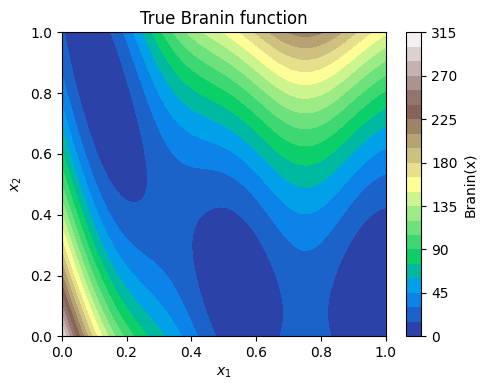

In [6]:
def branin(X):
    X = np.atleast_2d(X)
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return (
        (x2 - 5 / (4 * np.pi**2) * x1**2 + 5 / np.pi * x1 - 6) ** 2
        + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1)
        + 10
    )

# 50x50 evaluation grid
grid_x = np.linspace(0, 1, 50)
G1, G2  = np.meshgrid(grid_x, grid_x)
grid    = np.column_stack([G1.ravel(), G2.ravel()])
z_true  = branin(grid).reshape(50, 50)

plt.figure(figsize=(5, 4))
plt.contourf(G1, G2, z_true, levels=20, cmap='terrain')
plt.colorbar(label='Branin(x)')
plt.title('True Branin function')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

## 3. Design of experiments

We sample $n = 30$ points using a Latin Hypercube Design.

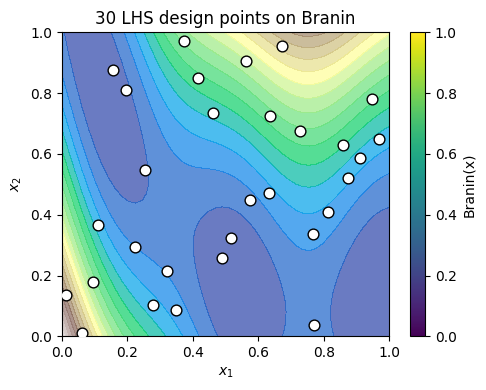

In [7]:
rng = np.random.default_rng(42)

def lhs(n, d, rng):
    """Simple LHS: stratified uniform sample, independently permuted per dimension."""
    X = np.empty((n, d))
    for j in range(d):
        perm = rng.permutation(n)
        X[:, j] = (perm + rng.uniform(size=n)) / n
    return X

n = 30
X = lhs(n, 2, rng)
y = branin(X)

plt.figure(figsize=(5, 4))
plt.contourf(G1, G2, z_true, levels=20, cmap='terrain', alpha=0.7)
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=60, zorder=5)
plt.colorbar(label='Branin(x)')
plt.title(f'{n} LHS design points on Branin')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

## 4. Fit a WarpKriging model (`kumaraswamy`)

We use `warping=['kumaraswamy', 'kumaraswamy']` — one warp per input dimension.

In [8]:
wk = lk.WarpKriging(
    y, X,
    warping=['kumaraswamy', 'kumaraswamy'],
    kernel='matern5_2',
    optim='BFGS+Adam',
    parameters={'max_iter_adam': '200'}
)
print(wk.summary())

* WarpKriging
* data: 30x[0.0123487,0.968794],[0.0120604,0.971744] -> 30x[4.11988,222.799]
* trend constant (est.): 2599.59
* variance (est.): 7.90338e+06
* covariance:
  * kernel: matern5_2
  * range (est.): 1.93814, 6.88294
  * warpings:
      x0: "kumaraswamy"  →  Kumaraswamy(a=1, b=1)
      x1: "kumaraswamy"  →  Kumaraswamy(a=1, b=1)
  * total warp params: 4
  * fit:
    * objective: LL
    * optim: BFGS+Adam



## 5. Predict on a fine grid

`predict()` returns `(mean, stdev, cov)`.

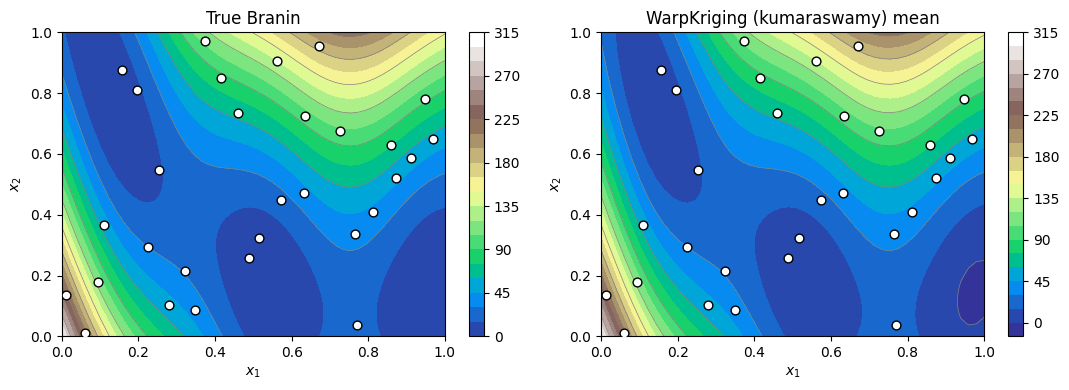

In [9]:
warp_name = 'kumaraswamy'
pred   = wk.predict(grid)
z_mean = pred[0].reshape(50, 50)
z_sd   = pred[1].reshape(50, 50)

vmin = min(z_true.min(), z_mean.min())
vmax = max(z_true.max(), z_mean.max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, z, title in zip(axes, [z_true, z_mean], ['True Branin', f'WarpKriging ({warp_name}) mean']):
    cf = ax.contourf(G1, G2, z, levels=20, cmap='terrain', vmin=vmin, vmax=vmax)
    ax.contour(G1, G2, z, levels=10, colors='grey', linewidths=0.5)
    ax.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=40, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    fig.colorbar(cf, ax=ax)

plt.tight_layout()
plt.show()

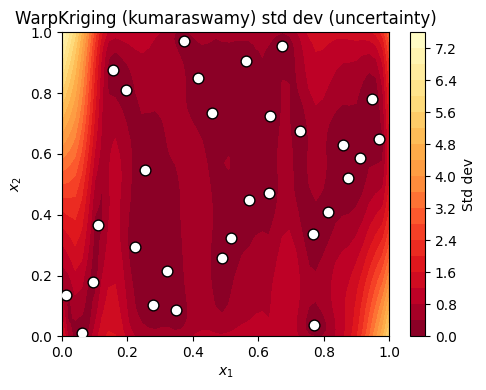

In [10]:
# Posterior standard deviation (uncertainty)
plt.figure(figsize=(5, 4))
cf = plt.contourf(G1, G2, z_sd, levels=20, cmap='YlOrRd_r')
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=60, zorder=5)
plt.colorbar(cf, label='Std dev')
plt.title('WarpKriging (kumaraswamy) std dev (uncertainty)')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

## 6. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, log-likelihood, and warping specification.

In [11]:
print(f"Kernel       : {wk.kernel()}")
print(f"Theta (range): {np.round(wk.theta(), 4)}")
print(f"Sigma2       : {wk.sigma2():.4f}")
print(f"LogLikelihood: {wk.logLikelihood():.4f}")
print(f"Feature dim  : {wk.feature_dim()}")
print(f"Warping      : {wk.warping()}")

Kernel       : matern5_2
Theta (range): [[1.9381]
 [6.8829]]
Sigma2       : 7903380.8392
LogLikelihood: -100.6397
Feature dim  : 2
Warping      : ['kumaraswamy', 'kumaraswamy']
